<a href="https://colab.research.google.com/github/rhodes-byu/cs-stat-180/blob/main/labs/08-clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><p><b>After clicking the "Open in Colab" link, copy the notebook to your own Google Drive before getting started, or it will not save your work</b></p>

One of the most straightforward tasks we can perform on a data set without labels is to find groups of data in our dataset which are similar to one another -- what we call clusters.

K-Means is one of the most popular "clustering" algorithms. K-means stores k centroids that it uses to define clusters. A point is considered to be in a particular cluster if it is closer to that cluster's centroid than any other centroid.

K-Means finds the best centroids by alternating between (1) assigning data points to clusters based on the current centroids (2) chosing centroids (points which are the center of a cluster) based on the current assignment of data points to clusters.

## Dataset: MNIST

### MNIST dataset — a brief overview

**Introduction**
The MNIST (Modified National Institute of Standards and Technology) dataset is a widely used benchmark in machine learning. It contains images of handwritten digits and is often used to teach and test classification and clustering techniques.

**Description**
- Type: Handwritten digit images  
- Size: 70,000 grayscale images (28 × 28 pixels)  
  - Training set: 60,000 images  
  - Test set: 10,000 images  
- Classes: 10 (digits 0–9)  
- Format: Each example is a flattened 784-dimensional vector (28×28 pixels) or a 28×28 image with pixel values in [0, 255].  

**Why use MNIST?**
- It is commonly used as a 'toy' dataset in machine learning.
- Simple and well-structured, so students can focus on methods rather than data cleaning.
- Large enough to illustrate practical issues (scaling, dimensionality reduction, speed) but small enough to run on a laptop when sampled.

**Accessing MNIST**
Use scikit-learn's `fetch_openml` to download the MNIST dataset:

```python
        from sklearn.datasets import fetch_openml
        mnist = fetch_openml('mnist_784', version=1, parser='auto')
        X, y = mnist['data'], mnist['target']
```

Format returned by `fetch_openml('mnist_784')`:
- `X`: a table-like object with 70,000 rows and 784 columns; each row is a flattened 28×28 image (pixels ordered 0...783). Pixel values are typically in the range 0–255.  
- `y`: labels for each row (digits 0–9), often returned as strings; convert to integers with `y = y.astype(int)` if desired.  
  

Quick note: to visualize a row as an image use: `X.iloc[i].values.reshape(28,28)` (or `X.values[i].reshape(28,28)`), then display with `plt.imshow(...)`.

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA
import seaborn as sns

# Set global random seed for the notebook
np.random.seed(42)

In [2]:
# Load MNIST dataset
mnist = fetch_openml('mnist_784', version = 1, parser = 'auto')
X, y = mnist['data'], mnist['target']

The MNIST digits in this set are flattened arrays of 784 pixels. We can reshape them to 28x28 pixels and plot them using matplotlib.

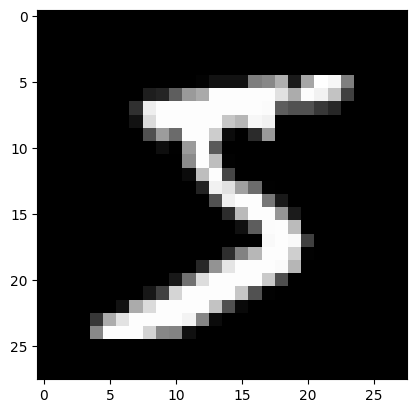

In [3]:
image = X.iloc[0, :].values.reshape((28, 28))
plt.imshow(image, cmap='gray')

### 1. Preparing the Data

a. Using the full dataset, *normalize* each image so that the minimum value is 0, and the maximum is 1. This is a standard practice for image datasets.  (Hint: the maximum pixel value is 255, the minimum is 0. How can we rescale this so the maximum is 1?)


In [4]:
X_norm = X / 255.0

b. Get a random sample of 10% of the data. You will use this sample for the remainder of the questions to reduce computation time.

In [5]:
sample_idx = X_norm.sample(frac=0.10, random_state=42).index
X_subset = X_norm.loc[sample_idx]
y_subset = y.loc[sample_idx]

### 2. Fitting k-Means

a. Using the MNIST subset, determine the optimal k value for k-means according to the WCSS elbow method. Use a range of k-values from 2 - 15. (Hint: The plot will not be cut and dry like some of the class examples; just use your best judgement!)

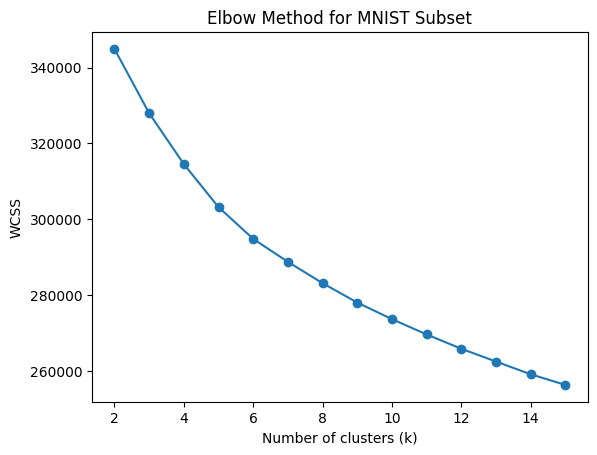

In [7]:
k_values = range(2, 16)
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_subset)
    wcss.append(kmeans.inertia_)

plt.plot(k_values, wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for MNIST Subset')
plt.show()

b. Fit a k-means model with the optimal k value.

In [8]:
optimal_k = 10
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_subset)

KMeans(n_clusters=10, n_init=10, random_state=42)

c. High-dimensional data—like MNIST digit images with 784 pixels—are hard to visualize.  
**Dimensionality reduction** helps us find a lower-dimensional view that keeps important patterns.

**Principal Component Analysis (PCA)** is a simple and fast method that finds directions of maximum variation in the data. By keeping only the top two directions, we can make a 2D version of our data that’s easy to plot.

Use **PCA** to reduce the MNIST data to **2 dimensions** (`n_components=2`).  
Then make a **scatterplot** of the 2D data and **color the points by their k-means cluster labels**. Use the Dark2 colormap to help distingish the colors. It will also be helpful to shrink the point size (e.g., s = 0.5).

**Hint:** Use [`sklearn.decomposition.PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).


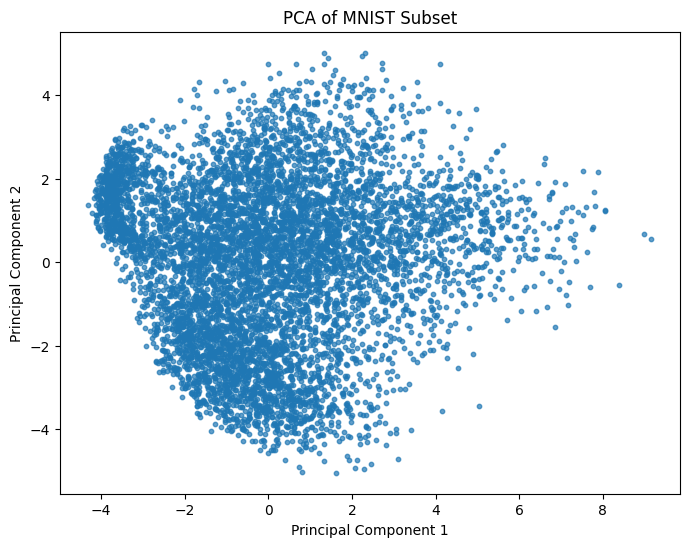

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_subset)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Subset')
plt.show()

d. Create two side-by-side scatterplots using the PCA representation (first two principal components) using plt.subplots. Color the first fig according to the true labels and the second according to k-means cluster labels. Be sure to include proper figure titles and a legend.

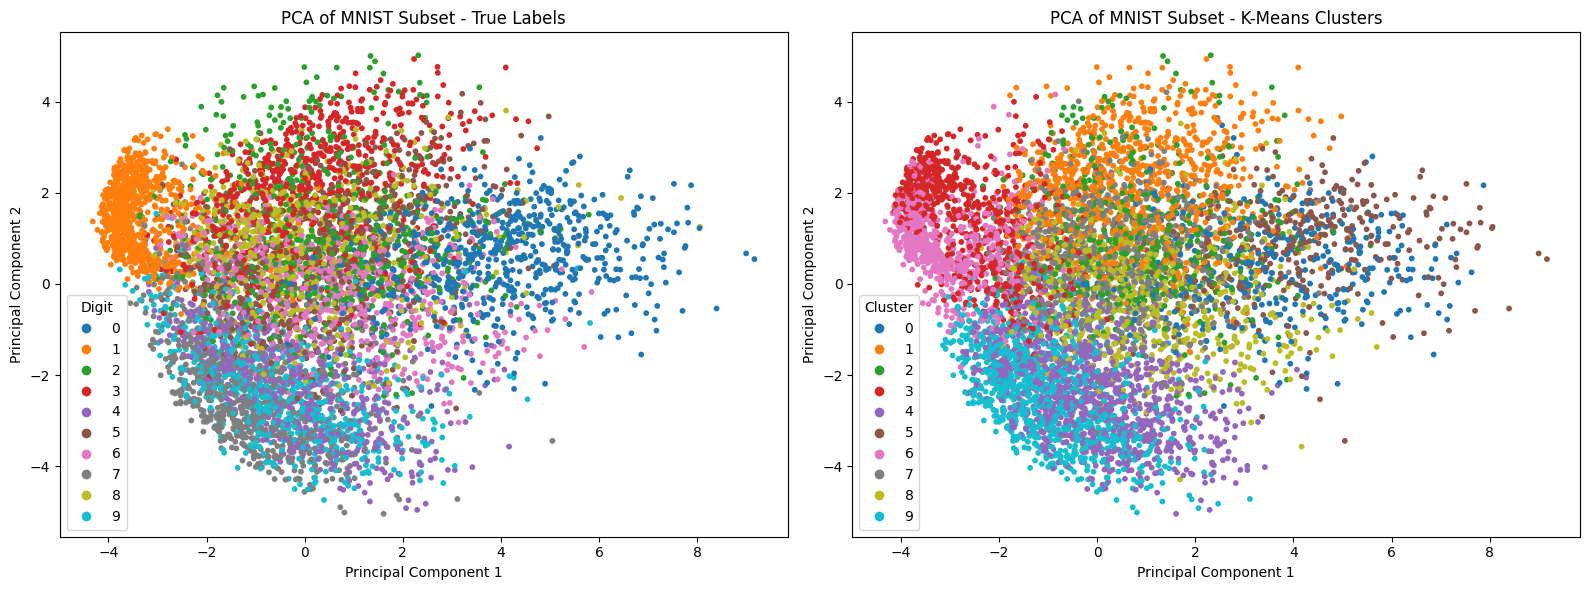

In [10]:
cluster_labels = kmeans.labels_
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_subset.astype(int), cmap='tab10', s=10)
axes[0].set_title('PCA of MNIST Subset - True Labels')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend(*scatter1.legend_elements(), title='Digit')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', s=10)
axes[1].set_title('PCA of MNIST Subset - K-Means Clusters')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].legend(*scatter2.legend_elements(), title='Cluster')

plt.tight_layout()
plt.show()

e. Describe the fit. Does this align with your expectation? (Note: The specific color used for the clusters and labels will not align, but do you see some of the same patterns emerge?)

f. Display the cluster centroids as images in a grid using subplots. What digits do they most resemble?

In [11]:
print("The match isn't perfect but it is very similar. This is because the k-means is unsupervised. Some also overlap.")

The match isn't perfect but it is very similar. This is because the k-means is unsupervised. Some also overlap.


### 3. Hierarchical Clustering
Here you will be performing hierarchical clustering on a smaller data subset.

Here you will be comparing linkage methods and metrics. Use the following linkage/metric combinations:

| Linkage Method | Metrics              |
|---------------|----------------------|
| Ward         | Euclidean            |
| Complete     | Euclidean, Cosine |

a. Get a subset of 10% of your original subset (you should have 700 points).

In [12]:
X_small = X_subset.sample(frac=0.1, random_state=42)

b. Fit hierarhiccal clustering with 10 clusters for each combination and store the silhouette scores.

In [13]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

scores = {}

# Ward + Euclidean
model = AgglomerativeClustering(n_clusters=10, linkage='ward')
labels = model.fit_predict(X_small)
scores['ward_euclidean'] = silhouette_score(X_small, labels)

# Complete + Euclidean
model = AgglomerativeClustering(n_clusters=10, linkage='complete', metric='euclidean')
labels = model.fit_predict(X_small)
scores['complete_euclidean'] = silhouette_score(X_small, labels)

# Complete + Cosine
model = AgglomerativeClustering(n_clusters=10, linkage='complete', metric='cosine')
labels = model.fit_predict(X_small)
scores['complete_cosine'] = silhouette_score(X_small, labels)

print(scores)

{'ward_euclidean': np.float64(0.04257497405017775), 'complete_euclidean': np.float64(0.048404054727476435), 'complete_cosine': np.float64(0.026158592844873322)}


c. According to the silhouette scores, which combination is best?

In [14]:
print("The best comnbination was complete linkage with cosine distance.")

The best comnbination was complete linkage with cosine distance.


### 4. Visualizing Clustered Digits

a. Pick one of the cluster labels from your best models (k-means or HC). Select a random subset of 20 points belonging to that cluster.  

In [15]:
best_model = AgglomerativeClustering(n_clusters=10, linkage='complete', metric='cosine')
best_labels = best_model.fit_predict(X_small)
chosen_cluster = 0
cluster_indices = X_small.index[best_labels == chosen_cluster]
sample_indices = pd.Series(cluster_indices).sample(n=20, random_state=42)
cluster_samples = X_small.loc[sample_indices]

b. Using subplots (4 rows, 5 columns), plot the 20 digit images.  

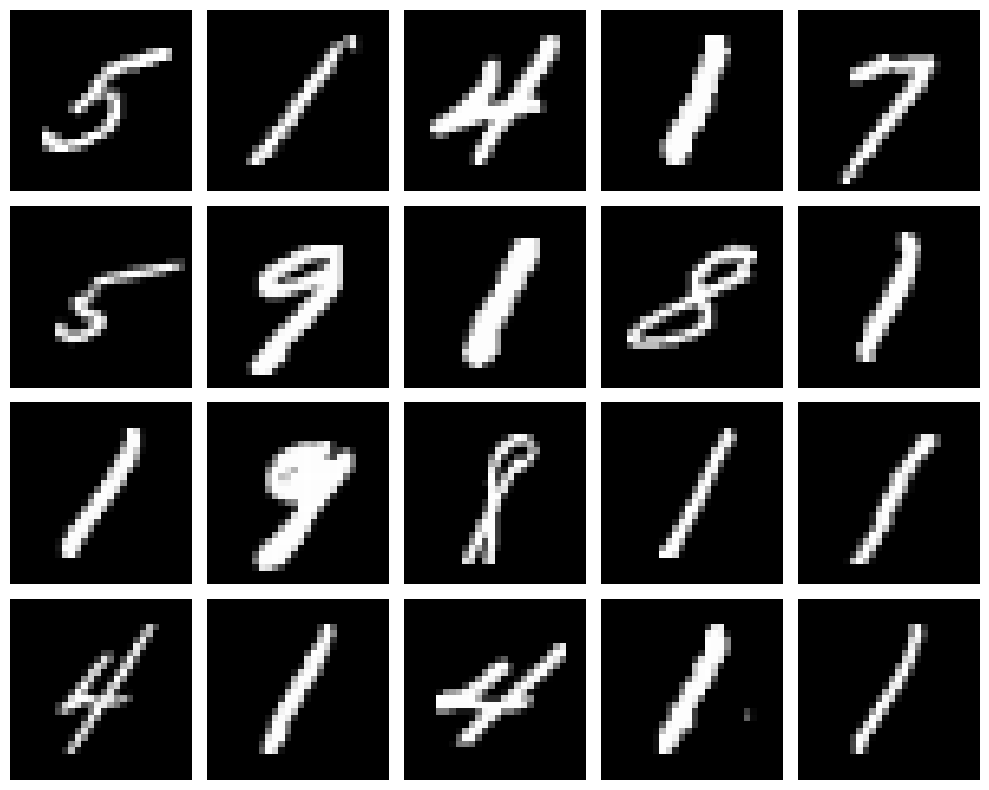

In [16]:
fig, axes = plt.subplots(4, 5, figsize=(10, 8))

for ax, (_, row) in zip(axes.flat, cluster_samples.iterrows()):
    ax.imshow(row.values.reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

c. Comment on the clustered points (e.g., do they look similar?, are the representing the same digit?, etc.)

The images look fairly similar but represent different digits at points. There's a lot of variation but some do represent the same digit.